# Базовая модель: разбиение выборок и SimpleCNN

- Разбиение на обучение / валидацию / тест (70/15/15)
- Загрузчик с масштабированием до 224×224 и нормализацией под ImageNet
- Обучение `SimpleCNN`
- Метрики на валидационной выборке

In [ ]:
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from dataset import BuildingDataset, CLASSES, build_combined_dataframe, get_transforms, make_split, save_split
from model import SimpleCNN

#Параметры
RANDOM_SEED = 42
DATA_ROOT = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
REPORTS_DIR = PROJECT_ROOT / 'reports'
SPLIT_CSV = PROJECT_ROOT / 'data' / 'processed' / 'split.csv'

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
BATCH_SIZE = 32
MAX_EPOCHS = 100
LOSS_EPS = 1e-4
PATIENCE = 7
MIN_EPOCHS = 25
LEARNING_RATE = 1e-3

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

# Фиксация случайного зерна для воспроизводимости
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)
if torch.cuda.is_available():
    print('ГПУ:', torch.cuda.get_device_name(0))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Устройство: cuda
ГПУ: NVIDIA GeForce RTX 4060 Laptop GPU


## Разбиение на обучение / валидацию / тест (70/15/15)

In [2]:
df = build_combined_dataframe(DATA_ROOT, classes=CLASSES)
print(f'Всего изображений: {len(df)}')

split_df = make_split(df, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=RANDOM_SEED)
save_split(split_df, SPLIT_CSV)

print('\nРазмеры выборок:')
_split_ru = {'train': 'обучение', 'val': 'валидация', 'test': 'тест'}
_split_counts = split_df['split'].value_counts().reindex(['train', 'val', 'test'])
_split_counts.index = [_split_ru[k] for k in _split_counts.index]
print(_split_counts)

print('\nРазбивка по классам:')
pivot = split_df.groupby(['class', 'split']).size().unstack().reindex(CLASSES)
pivot = pivot.rename(columns=_split_ru)
print(pivot)

Всего изображений: 3139

Размеры выборок:
split
train    2197
val       471
test      471
Name: count, dtype: int64

Разбивка по классам:
split               test  train  val
class                               
commercial           117    544  116
industrial           125    582  124
dense_residential    121    566  122
sparse_residential   108    505  109


## Загрузчик данных

- Изменение размера до 224×224
- Нормализация под статистику ImageNet

In [3]:
transform = get_transforms(image_size=224)

train_ds = BuildingDataset(split_df, split='train', classes=CLASSES, transform=transform)
val_ds = BuildingDataset(split_df, split='val', classes=CLASSES, transform=transform)
test_ds = BuildingDataset(split_df, split='test', classes=CLASSES, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Обучение: {len(train_ds)} | Валидация: {len(val_ds)} | Тест: {len(test_ds)}')

sample_img, sample_label = train_ds[0]
print(f'Форма тензора картинки: {sample_img.shape}')
print(f'Класс примера: {CLASSES[sample_label]}')
print(f'Диапазон значений после нормализации: [{sample_img.min():.2f}, {sample_img.max():.2f}]')

Обучение: 2197 | Валидация: 471 | Тест: 471
Форма тензора картинки: torch.Size([3, 224, 224])
Класс примера: commercial
Диапазон значений после нормализации: [-1.25, 2.64]


## Базовая модель — SimpleCNN

Архитектура: четыре слоя свёртки, усреднение по карте признаков, случайное отключение части связей, итоговый классификатор. Веса не предобучены.

In [4]:
model = SimpleCNN(num_classes=len(CLASSES)).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Параметров в модели: {n_params:,}')
print(model)

Параметров в модели: 390,404
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256

## Обучение

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, model, criterion, optimizer=None):
    """Один проход по данным. Если optimizer передан — режим обучения, иначе — оценка."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, macro_f1

def _loss_plateau(val_losses, eps=LOSS_EPS, patience=PATIENCE):
    if len(val_losses) < patience + 1:
        return False
    recent = val_losses[-patience:]
    deltas = [abs(recent[i] - recent[i - 1]) for i in range(1, len(recent))]
    return all(d < eps for d in deltas)

In [6]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
best_epoch = 0
best_model_path = MODELS_DIR / 'baseline_model.pth'

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc, _ = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Сохранение лучшей модели по macro F1 на валидации
    is_best = val_f1 > best_val_f1
    if is_best:
        best_val_f1 = val_f1
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)

    marker = ' <- лучшая' if is_best else ''
    print(
        f'Эпоха {epoch:3d}/{MAX_EPOCHS} | '
        f'потери_обуч={train_loss:.4f} точн_обуч={train_acc:.4f} | '
        f'потери_вал={val_loss:.4f} точн_вал={val_acc:.4f} macro F1={val_f1:.4f} | '
        f'{time.time() - t0:.1f}s{marker}'
    )

    if epoch >= MIN_EPOCHS and _loss_plateau(history['val_loss'], LOSS_EPS, PATIENCE):
        print(f'Ранняя остановка при |Δ| < {LOSS_EPS} в течение {PATIENCE} эпох')
        break

epochs_run = len(history['train_loss'])
print(f'\nЛучший macro F1 на валидации: {best_val_f1:.4f} (эпоха {best_epoch}/{epochs_run})')
print(f'Модель сохранена: {best_model_path}')

Эпоха   1/100 | потери_обуч=0.6735 точн_обуч=0.7469 | потери_вал=0.6602 точн_вал=0.7261 f1=0.7266 | 21.8s <- лучшая
Эпоха   2/100 | потери_обуч=0.5251 точн_обуч=0.8088 | потери_вал=0.8014 точн_вал=0.7155 f1=0.7067 | 19.5s
Эпоха   3/100 | потери_обуч=0.4803 точн_обуч=0.8266 | потери_вал=0.3982 точн_вал=0.8662 f1=0.8669 | 18.0s <- лучшая
Эпоха   4/100 | потери_обуч=0.4293 точн_обуч=0.8384 | потери_вал=0.5786 точн_вал=0.7877 f1=0.7829 | 18.9s
Эпоха   5/100 | потери_обуч=0.4255 точн_обуч=0.8416 | потери_вал=0.3992 точн_вал=0.8769 f1=0.8797 | 16.4s <- лучшая
Эпоха   6/100 | потери_обуч=0.3786 точн_обуч=0.8557 | потери_вал=0.3307 точн_вал=0.8854 f1=0.8870 | 17.3s <- лучшая
Эпоха   7/100 | потери_обуч=0.3719 точн_обуч=0.8598 | потери_вал=0.5304 точн_вал=0.7983 f1=0.8003 | 17.7s
Эпоха   8/100 | потери_обуч=0.3523 точн_обуч=0.8703 | потери_вал=0.8108 точн_вал=0.6879 f1=0.6747 | 21.0s
Эпоха   9/100 | потери_обуч=0.3586 точн_обуч=0.8698 | потери_вал=0.8101 точн_вал=0.7473 f1=0.7208 | 18.8s
Эпоха 

## Кривые обучения

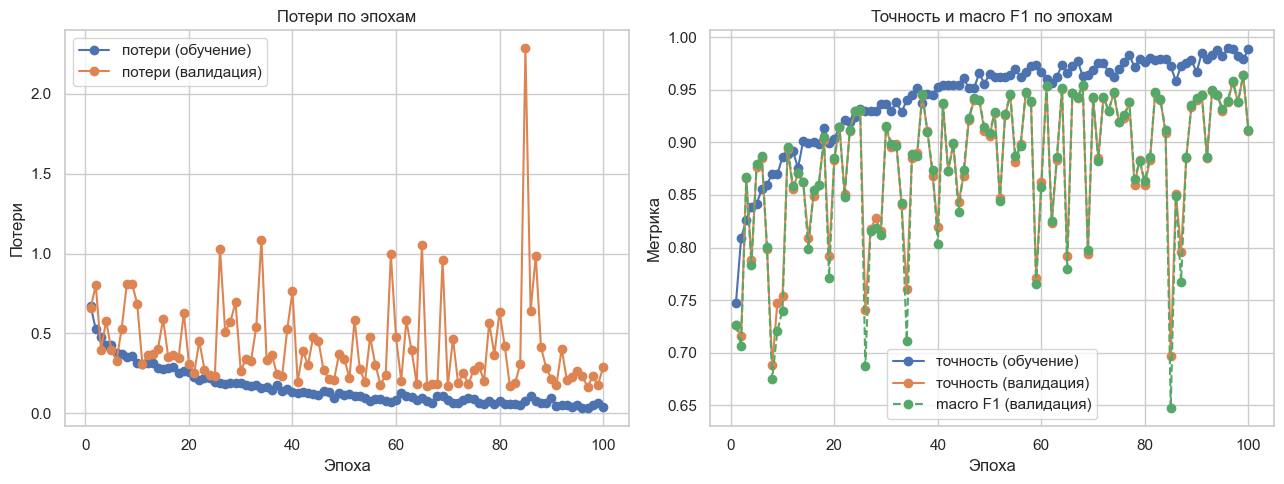

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs_range, history['train_loss'], label='потери (обучение)', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='потери (валидация)', marker='o')
axes[0].set_title('Потери по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='точность (обучение)', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='точность (валидация)', marker='o')
axes[1].plot(epochs_range, history['val_f1'], label='macro F1 (валидация)', marker='o', linestyle='--')
axes[1].set_title('Точность и macro F1 по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Метрика')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'baseline_training_curves.png', dpi=100)
plt.show()

## Метрики на валидационной выборке (лучшая модель)

In [8]:
# Загрузка лучшей по macro F1 модели
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

val_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
val_macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f'Точность на валидации: {val_accuracy:.4f}')
print(f'macro F1 на валидации: {val_macro_f1:.4f}')
print()
def print_classification_report_ru(y_true, y_pred, target_names):
    """Отчёт классификации с русскими заголовками."""
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0)
    print(f"{'класс':<22} {'прециз.':>8} {'полнота':>8} {'F1':>8} {'объектов':>8}")
    for name in target_names:
        r = report[name]
        print(f"{name:<22} {r['precision']:8.2f} {r['recall']:8.2f} {r['f1-score']:8.2f} {int(r['support']):8d}")
    n = int(report['macro avg']['support'])
    print(f"{'точность':<22} {report['accuracy']:8.2f} {'':>8} {'':>8} {n:8d}")
    m = report['macro avg']
    print(f"{'среднее macro':<22} {m['precision']:8.2f} {m['recall']:8.2f} {m['f1-score']:8.2f} {n:8d}")
    w = report['weighted avg']
    print(f"{'среднее взвеш.':<22} {w['precision']:8.2f} {w['recall']:8.2f} {w['f1-score']:8.2f} {n:8d}")


print('Отчёт классификации:')
print_classification_report_ru(all_labels, all_preds, CLASSES)

Точность на валидации: 0.9639
macro F1 на валидации: 0.9644

Отчёт классификации:
                    precision    recall  f1-score   support

        commercial       0.94      0.96      0.95       116
        industrial       0.96      0.98      0.97       124
 dense_residential       0.97      0.93      0.95       122
sparse_residential       0.99      0.99      0.99       109

          accuracy                           0.96       471
         macro avg       0.96      0.96      0.96       471
      weighted avg       0.96      0.96      0.96       471



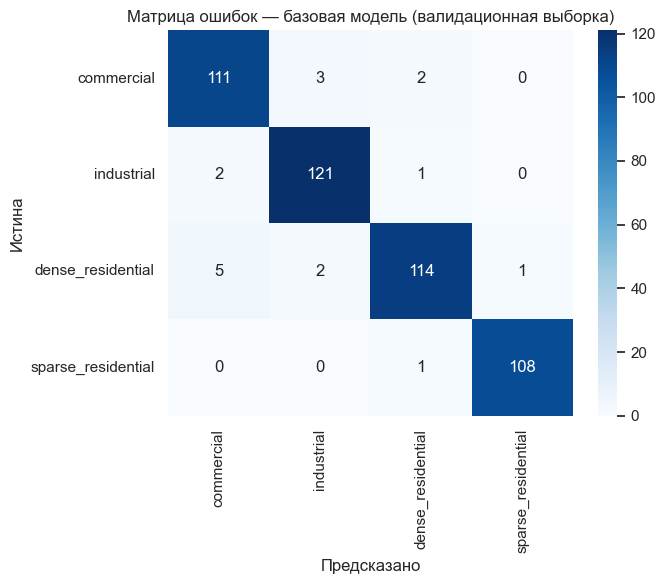

In [9]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок — базовая модель (валидационная выборка)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'baseline_confusion_matrix.png', dpi=100)
plt.show()

## Выводы

1. **Качество:** macro F1 = 0.9644, точность = 0.9639 на валидации (471 изображение). 

2. **Динамика обучения:** лучшее сохранённое состояние — 99-я эпоха, не последняя.

3. **Классы:** лучше всего `sparse_residential` (F1 ≈ 0.99). Слабее всего предсказание у `dense_residential` (0.93) — часть плотной жилой застройки классифицируется неверно. Ошибки между `commercial`, `industrial` и `dense_residential` — визуально близкие паттерны с высоты (см. матрицу ошибок).

In [11]:
report_dict = classification_report(
    all_labels, all_preds, target_names=CLASSES, output_dict=True, zero_division=0
)
worst_class = min(CLASSES, key=lambda c: report_dict[c]['f1-score'])
best_class = max(CLASSES, key=lambda c: report_dict[c]['f1-score'])

train_acc_at_best = history['train_acc'][best_epoch - 1]
val_acc_at_best = history['val_acc'][best_epoch - 1]
train_loss_at_best = history['train_loss'][best_epoch - 1]
val_loss_at_best = history['val_loss'][best_epoch - 1]
acc_gap = train_acc_at_best - val_acc_at_best

last_f1 = history['val_f1'][-1]
early_stopped = epochs_run < MAX_EPOCHS

print('=' * 55)
print('ИТОГИ БАЗОВОЙ МОДЕЛИ')
print('=' * 55)
print(f'Разбиение: обучение={len(train_ds)} валидация={len(val_ds)} тест={len(test_ds)} (70/15/15)')
print(f'Модель: SimpleCNN ({n_params:,} параметров)')
print()
print(f'Эпох обучено: {epochs_run}/{MAX_EPOCHS}')
if early_stopped:
    print(f'Ранняя остановка: сработала (|Δ| < {LOSS_EPS} в течение {PATIENCE} эпох)')
else:
    print('Ранняя остановка: не сработала — потери на валидации продолжали колебаться сильнее порога')
print(f'Лучшая эпоха (по macro F1): {best_epoch}/{epochs_run}')
print(f'  macro F1={best_val_f1:.4f}, точность={val_accuracy:.4f}')
print(f'  точность обучения={train_acc_at_best:.4f}, точность валидации={val_acc_at_best:.4f}, разрыв={acc_gap:.4f}')
print(f'  потери обучения={train_loss_at_best:.4f}, потери валидации={val_loss_at_best:.4f}')
if best_epoch != epochs_run:
    print(f'Последняя эпоха: macro F1={last_f1:.4f} (хуже лучшей на {best_val_f1 - last_f1:.4f})')
print()
print('Классы:')
print(f'  лучший  — {best_class}: F1={report_dict[best_class]["f1-score"]:.4f}')
print(f'  слабый  — {worst_class}: F1={report_dict[worst_class]["f1-score"]:.4f}, '
      f'полнота={report_dict[worst_class]["recall"]:.4f}')
print()
print(f'Модель сохранена: {best_model_path}')
print(f'Разбиение сохранено: {SPLIT_CSV}')

ИТОГИ БАЗОВОЙ МОДЕЛИ
Разбиение: обучение=2197 валидация=471 тест=471 (70/15/15)
Модель: SimpleCNN (390,404 параметров)

Эпох обучено: 100/100
Ранняя остановка: не сработала — потери на валидации продолжали колебаться сильнее порога
Лучшая эпоха (по macro F1): 99/100
  macro F1=0.9644, точность=0.9639
  точность обучения=0.9791, точность валидации=0.9639, разрыв=0.0152
  потери обучения=0.0618, потери валидации=0.1757
Последняя эпоха: macro F1=0.9121 (хуже лучшей на 0.0522)

Классы:
  лучший  — sparse_residential: F1=0.9908
  слабый  — commercial: F1=0.9487, полнота=0.9569

Модель сохранена: D:\building-type-classification\models\baseline_model.pth
Разбиение сохранено: D:\building-type-classification\data\processed\split.csv
